# Step 1b · Silver — returns and inventory

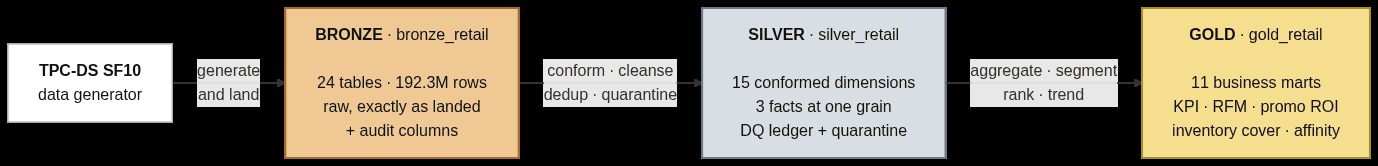

Two more facts, split into their own notebook purely so a failure in one does not cost
the other. Both get the same treatment as `fct_sales` in step 1: conform the channels,
dedup the replays, type the columns, stamp the lineage.

> **Each notebook runs in its own kernel**, so the helpers from step 1 are redefined
> here rather than inherited. Nothing carries over between notebooks.


In [ ]:
# =====================================================================
# MEDALLION / RETAIL  ·  STEP 1b — THE TWO HEAVY FACTS
# ---------------------------------------------------------------------
# Silver is the trusted, modelled layer. Everything here is deliberate:
#
#   * TYPE      — explicit decimals/dates/ints, never inferred
#   * DEDUP     — CDC replays and MDM re-sends collapsed on natural keys
#   * CONFORM   — three sales channels (store / catalog / web) unified into
#                 ONE fact grain; three return feeds into another
#   * STANDARD  — trimmed names, upper-cased states, one spelling per country
#   * ENRICH    — customer + demographics + household + income band -> one
#                 dimension; business-readable column names throughout
#   * QUARANTINE— rows that fail the contract go to a reject table, they do
#                 not silently vanish and they do not pollute the facts
#   * MEASURE   — every rule writes a row into silver_retail.dq_metrics
#
# Part B of silver: fct_returns and fct_inventory (133M rows), split out
# of 01 so each run stays inside the platform's ~22 min job ceiling.
# =====================================================================
import time
from pyspark.sql import SparkSession, functions as F, Window as W
from pyspark.sql.types import StructType, StructField, StringType, LongType, TimestampType

# ---------------------------------------------------------------------
# DEMO CONSOLE — live, readable progress
# ---------------------------------------------------------------------
# Every helper below flushes. Spark steps here take tens of seconds, and
# without an explicit flush a notebook's output can arrive in one burst at the
# very end — which reads as "nothing is happening" to an audience watching.
# Each step also announces itself BEFORE the work starts, so the pause is
# narrated rather than silent, and reports rows plus throughput when it lands.
import builtins as _bi
import functools as _ft
print = _ft.partial(_bi.print, flush=True)

_W = 78


def fmt(n):
    return "{:,}".format(int(n))


def rule(ch="─"):
    print(ch * _W)


def banner(title, subtitle=""):
    print()
    print("╔" + "═" * (_W - 2) + "╗")
    print("║ " + title.ljust(_W - 3) + "║")
    if subtitle:
        print("║ " + subtitle.ljust(_W - 3) + "║")
    print("╚" + "═" * (_W - 2) + "╝")


def section(num, title):
    print()
    print("▸ %s  %s" % (num, title))
    rule()


def working(msg):
    print("   … %s" % msg)


def ok(name, rows, secs, note=""):
    rate = "%12s rows/s" % fmt(rows / secs) if secs > 0.05 else " " * 18
    print("   ✓ %-28s %14s rows %7.1fs %s%s" % (name, fmt(rows), secs, rate, note))


def skipped(name, rows, what="already built"):
    print("   ~ %-28s %14s rows       —   %s" % (name, fmt(rows), what))


def metric(table, rule_name, value):
    print("       · %-20s %-30s %12s" % (table, rule_name, fmt(value)))


def finished(t0, what):
    print()
    rule("═")
    print("  %s COMPLETE in %.1fs" % (what.upper(), time.time() - t0))
    rule("═")

BRONZE_DB = "bronze_retail"
SILVER_DB = "silver_retail"

spark = SparkSession.builder.appName("medallion-silver").getOrCreate()
# 8 cores, and at demo scale every shuffle is a few hundred thousand rows. The
# default 200 partitions turns a 2-second write into 20 seconds of pure task
# scheduling; 16 keeps every core busy with none of that overhead.
spark.conf.set("spark.sql.shuffle.partitions", "16")
spark.conf.set("spark.sql.adaptive.enabled", "true")
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")

# Same demo slice as step 1 — see the note there. Dimensions stay whole; only
# the facts are cut, on a hash of the natural key so CDC replays stay together.
KEEP_PCT = 5

def demo_slice(df, *key_cols):
    if KEEP_PCT >= 100:
        return df
    return df.filter(F.abs(F.hash(*[F.col(c) for c in key_cols])) % 100 < KEEP_PCT)
spark.conf.set("spark.sql.sources.partitionOverwriteMode", "dynamic")
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", str(64 * 1024 * 1024))
# A Parquet writer buffers a whole row group in the heap. The default 128 MB,
# times one writer per concurrent task, does not fit a 2.85 GB driver, so
# trade a little compression for headroom.
spark.sparkContext._jsc.hadoopConfiguration().setInt("parquet.block.size", 32 * 1024 * 1024)

spark.sql(f"CREATE DATABASE IF NOT EXISTS {SILVER_DB} "
          f"COMMENT 'Conformed, cleansed, deduplicated retail model — the trusted layer'")

BATCH_ID = (spark.table(f"{BRONZE_DB}.store_sales")
                 .select("_batch_id").limit(1).collect()[0]["_batch_id"])
T_RUN = time.time()
banner("SILVER  ·  FACTS, RETURNS & INVENTORY",
       "the remaining grain — one row per line item")
print("   silver database   : %s" % SILVER_DB)
print("   processing batch  : %s" % BATCH_ID)
print("   shuffle partitions: %s" % spark.conf.get("spark.sql.shuffle.partitions"))
rule()

DQ = []            # (table, rule, scope, value) — flushed to dq_metrics at the end
STAGE_TIMES = {}


def dq(table, rule, scope, value):
    DQ.append((table, rule, scope, int(value)))
    metric(table, rule, value)


def bronze(name):
    """Read a bronze table and drop the landing-zone audit columns."""
    df = spark.table(f"{BRONZE_DB}.{name}")
    return df.drop("_source_system", "_source_file", "_batch_id", "_ingest_ts")


def publish(df, name, partition_by=None, files=None, comment=""):
    t0 = time.time()
    if already_done(name):
        n = spark.table(f"{SILVER_DB}.{name}").count()
        skipped(name, n, "already written for this batch")
        return n
    if files:
        df = df.repartition(files)
    if partition_by:
        # Sorted input means each task fills one Hive partition at a time and
        # keeps a single Parquet writer open instead of one per year.
        df = df.sortWithinPartitions(partition_by)
    writer = (df.withColumn("_silver_batch_id", F.lit(BATCH_ID))
                .withColumn("_silver_ts", F.current_timestamp())
                .write.mode("overwrite").format("parquet").option("compression", "snappy"))
    if partition_by:
        writer = writer.partitionBy(partition_by)
    writer.saveAsTable(f"{SILVER_DB}.{name}")
    if comment:
        spark.sql(f"ALTER TABLE {SILVER_DB}.{name} SET TBLPROPERTIES ('comment' = '{comment}')")
    n = spark.table(f"{SILVER_DB}.{name}").count()
    STAGE_TIMES[name] = time.time() - t0
    print("  ✓ %-26s %14s rows  %6.1fs" % (name, "{:,}".format(n), STAGE_TIMES[name]))
    return n


# Runs are capped at roughly 22 minutes on this platform, so every step is
# idempotent: a table already written for THIS bronze batch is left alone.
# Re-running a notebook therefore resumes instead of starting over.
# Set False to force a clean rebuild — needed after changing KEEP_PCT, since the
# staged tables from a previous scale would otherwise be skipped and silently
# reused. A full rebuild at demo scale takes about two minutes.
SKIP_EXISTING = True


def already_done(name, stamped=True):
    if not SKIP_EXISTING:
        return False
    try:
        t = spark.table(f"{SILVER_DB}.{name}")
        if stamped and "_silver_batch_id" in t.columns:
            got = t.select("_silver_batch_id").limit(1).collect()
            return bool(got) and got[0][0] == BATCH_ID
        return bool(t.limit(1).collect())
    except Exception:
        return False


def stage(df, name):
    """Materialise an intermediate result to disk. On a small driver heap this
    beats .cache() — the heap cannot hold tens of millions of rows, and a
    spilled cache is slower to re-read than plain Parquet."""
    if already_done(name, stamped=False):
        print("  · staged %-20s   SKIPPED (already present)" % name)
        return
    t0 = time.time()
    df.write.mode("overwrite").format("parquet").saveAsTable(f"{SILVER_DB}.{name}")
    print("  · staged %-20s %6.1fs" % (name, time.time() - t0))


def dedup(df, keys, order_col=None):
    """Keep one row per natural key — last one wins, as a CDC merge would."""
    order = F.col(order_col).desc() if order_col else F.lit(1)
    w = W.partitionBy(*[F.col(k) for k in keys]).orderBy(order)
    return (df.withColumn("_rn", F.row_number().over(w))
              .filter(F.col("_rn") == 1).drop("_rn"))

print("helpers ready")


### 1.8 · Returns — the same conforming treatment, three more feeds

`store_returns`, `catalog_returns` and `web_returns` conform onto one canonical
returns schema, exactly as the sales feeds did. Once this lands, *"return rate by
channel"* becomes a single join instead of a research project.


In [ ]:
# ---------------------------------------------------------------------
# 1.8  fct_returns — the same conforming treatment for three return feeds
# ---------------------------------------------------------------------

section("1.8", "RETURNS — THE SAME CONFORMING TREATMENT, THREE MORE FEEDS")
def conform(df, canon, mapping, channel):
    """Project a channel-specific table onto the canonical schema.
    A column the channel does not have becomes a typed NULL, not an error.

    Defined here as well as in step 1: each notebook runs in its own kernel, so
    nothing carries over between them."""
    cols, missing = [], []
    for name, dtype in canon:
        src = mapping.get(name)
        if src and src in df.columns:
            cols.append(F.col(src).cast(dtype).alias(name))
        else:
            missing.append(name)
            cols.append(F.lit(None).cast(dtype).alias(name))
    if missing:
        print("      %-8s has no: %s" % (channel, ", ".join(missing)))
    return df.select(*cols).withColumn("channel", F.lit(channel))

CANON_RET = [
    ("returned_date_sk", "int"), ("returned_time_sk", "int"), ("item_sk", "int"),
    ("customer_sk", "int"), ("returning_customer_sk", "int"), ("address_sk", "int"),
    ("store_sk", "int"), ("call_center_sk", "int"), ("catalog_page_sk", "int"),
    ("web_page_sk", "int"), ("ship_mode_sk", "int"), ("warehouse_sk", "int"),
    ("reason_sk", "int"), ("order_number", "bigint"), ("return_quantity", "int"),
    ("return_amount", "decimal(7,2)"), ("return_tax", "decimal(7,2)"),
    ("return_amt_inc_tax", "decimal(7,2)"), ("return_fee", "decimal(7,2)"),
    ("return_ship_cost", "decimal(7,2)"), ("refunded_cash", "decimal(7,2)"),
    ("reversed_charge", "decimal(7,2)"), ("store_credit", "decimal(7,2)"),
    ("net_loss", "decimal(7,2)"),
]

RET_MAP = {
 "STORE": ("store_returns", {
    "returned_date_sk":"sr_returned_date_sk", "returned_time_sk":"sr_return_time_sk",
    "item_sk":"sr_item_sk", "customer_sk":"sr_customer_sk", "address_sk":"sr_addr_sk",
    "store_sk":"sr_store_sk", "reason_sk":"sr_reason_sk", "order_number":"sr_ticket_number",
    "return_quantity":"sr_return_quantity", "return_amount":"sr_return_amt",
    "return_tax":"sr_return_tax", "return_amt_inc_tax":"sr_return_amt_inc_tax",
    "return_fee":"sr_fee", "return_ship_cost":"sr_return_ship_cost",
    "refunded_cash":"sr_refunded_cash", "reversed_charge":"sr_reversed_charge",
    "store_credit":"sr_store_credit", "net_loss":"sr_net_loss"}),
 "CATALOG": ("catalog_returns", {
    "returned_date_sk":"cr_returned_date_sk", "returned_time_sk":"cr_returned_time_sk",
    "item_sk":"cr_item_sk", "customer_sk":"cr_refunded_customer_sk",
    "returning_customer_sk":"cr_returning_customer_sk", "address_sk":"cr_refunded_addr_sk",
    "call_center_sk":"cr_call_center_sk", "catalog_page_sk":"cr_catalog_page_sk",
    "ship_mode_sk":"cr_ship_mode_sk", "warehouse_sk":"cr_warehouse_sk",
    "reason_sk":"cr_reason_sk", "order_number":"cr_order_number",
    "return_quantity":"cr_return_quantity", "return_amount":"cr_return_amount",
    "return_tax":"cr_return_tax", "return_amt_inc_tax":"cr_return_amt_inc_tax",
    "return_fee":"cr_fee", "return_ship_cost":"cr_return_ship_cost",
    "refunded_cash":"cr_refunded_cash", "reversed_charge":"cr_reversed_charge",
    "store_credit":"cr_store_credit", "net_loss":"cr_net_loss"}),
 "WEB": ("web_returns", {
    "returned_date_sk":"wr_returned_date_sk", "returned_time_sk":"wr_returned_time_sk",
    "item_sk":"wr_item_sk", "customer_sk":"wr_refunded_customer_sk",
    "returning_customer_sk":"wr_returning_customer_sk", "address_sk":"wr_refunded_addr_sk",
    "web_page_sk":"wr_web_page_sk", "reason_sk":"wr_reason_sk",
    "order_number":"wr_order_number", "return_quantity":"wr_return_quantity",
    "return_amount":"wr_return_amt", "return_tax":"wr_return_tax",
    "return_amt_inc_tax":"wr_return_amt_inc_tax", "return_fee":"wr_fee",
    "return_ship_cost":"wr_return_ship_cost", "refunded_cash":"wr_refunded_cash",
    "reversed_charge":"wr_reversed_charge", "store_credit":"wr_account_credit",
    "net_loss":"wr_net_loss"}),
}

raw_ret = None
for channel, (tbl, mapping) in RET_MAP.items():
    part = conform(bronze(tbl), CANON_RET, mapping, channel)
    raw_ret = part if raw_ret is None else raw_ret.unionByName(part)

raw_ret = demo_slice(raw_ret, "channel", "order_number", "item_sk")
n_raw_r = raw_ret.count()
dq("fct_returns", "bronze rows (3 channels)", "in", n_raw_r)

ret = dedup(raw_ret, ["channel", "order_number", "item_sk"], "returned_date_sk")
n_dedup_r = ret.count()
dq("fct_returns", "duplicate lines removed", "clean", n_raw_r - n_dedup_r)

ret_date = spark.table(f"{SILVER_DB}.dim_date").select(
    F.col("date_sk").alias("_dsk"), F.col("calendar_date").alias("returned_date"),
    F.col("calendar_year").alias("returned_year"), F.col("year_month").alias("returned_year_month"))

fct_returns = (ret
    .filter(F.col("returned_date_sk").isNotNull() & F.col("item_sk").isNotNull())
    .join(F.broadcast(ret_date), F.col("returned_date_sk") == F.col("_dsk"), "left").drop("_dsk")
    .withColumn("return_line_sk",
                F.sha2(F.concat_ws("|", F.col("channel"), F.col("order_number"),
                                   F.col("item_sk")), 256).substr(1, 32))
    .withColumn("total_refund",
                (F.coalesce(F.col("refunded_cash"), F.lit(0)) +
                 F.coalesce(F.col("reversed_charge"), F.lit(0)) +
                 F.coalesce(F.col("store_credit"), F.lit(0))).cast("decimal(9,2)"))
    .withColumn("refund_method",
                F.when(F.col("refunded_cash") >= F.greatest(
                            F.coalesce(F.col("reversed_charge"), F.lit(0)),
                            F.coalesce(F.col("store_credit"), F.lit(0))), "CASH")
                 .when(F.col("reversed_charge") >= F.coalesce(F.col("store_credit"), F.lit(0)), "CARD_REVERSAL")
                 .otherwise("STORE_CREDIT"))
    .filter(F.col("returned_year").isNotNull()))

n = publish(fct_returns, "fct_returns", partition_by="returned_year", files=4,
            comment="Conformed returns fact across store, catalog and web")
dq("fct_returns", "rows published", "out", n)


### 1.9 · Inventory — the largest table in the estate

A weekly stock snapshot per item per warehouse. This one is **not sliced** — it lands
at full volume, 6.65 million rows, in about 19 seconds. It feeds the stock-cover and
out-of-stock analysis in gold.

§1.10 then appends to the same `dq_metrics` ledger step 1 started, so the audit record
covers the whole silver layer rather than half of it.


In [ ]:
# ---------------------------------------------------------------------
# 1.9  fct_inventory — the largest table in the estate, typed and dated
# ---------------------------------------------------------------------
section("1.9", "INVENTORY — THE LARGEST TABLE IN THE ESTATE")
inv = demo_slice(bronze("inventory"),
                 "inv_item_sk", "inv_warehouse_sk", "inv_date_sk")
dq("fct_inventory", "bronze rows", "in", inv.count())

inv_date = spark.table(f"{SILVER_DB}.dim_date").select(
    F.col("date_sk").alias("_dsk"), F.col("calendar_date").alias("snapshot_date"),
    F.col("calendar_year").alias("snapshot_year"), F.col("week_seq").alias("snapshot_week_seq"))

fct_inventory = (inv
    .select(
        F.col("inv_date_sk").cast("int").alias("snapshot_date_sk"),
        F.col("inv_item_sk").cast("int").alias("item_sk"),
        F.col("inv_warehouse_sk").cast("int").alias("warehouse_sk"),
        F.col("inv_quantity_on_hand").cast("int").alias("quantity_on_hand"))
    .filter(F.col("snapshot_date_sk").isNotNull() & F.col("item_sk").isNotNull())
    .join(F.broadcast(inv_date), F.col("snapshot_date_sk") == F.col("_dsk"), "left").drop("_dsk")
    .withColumn("quantity_on_hand", F.coalesce(F.col("quantity_on_hand"), F.lit(0)))
    .withColumn("is_out_of_stock", F.col("quantity_on_hand") <= 0)
    .withColumn("stock_band",
        F.when(F.col("quantity_on_hand") <= 0, "OUT_OF_STOCK")
         .when(F.col("quantity_on_hand") < 100, "LOW")
         .when(F.col("quantity_on_hand") < 500, "HEALTHY")
         .otherwise("OVERSTOCKED"))
    .filter(F.col("snapshot_year").isNotNull()))

n = publish(fct_inventory, "fct_inventory", partition_by="snapshot_year", files=12,
            comment="Weekly item/warehouse stock position with stockout flags")
dq("fct_inventory", "rows published", "out", n)
dq("fct_inventory", "out-of-stock snapshots", "out",
   spark.table(f"{SILVER_DB}.fct_inventory").filter("is_out_of_stock").count())

# %
# ---------------------------------------------------------------------
# 1.10  Persist this part's slice of the data-quality ledger
# ---------------------------------------------------------------------
schema = StructType([
    StructField("table_name", StringType()), StructField("rule", StringType()),
    StructField("scope", StringType()), StructField("metric_value", LongType()),
])
(spark.createDataFrame(DQ, schema)
      .withColumn("batch_id", F.lit(BATCH_ID))
      .withColumn("measured_at", F.current_timestamp())
      .repartition(1)
      .write.mode("append").format("parquet")
      .saveAsTable(f"{SILVER_DB}.dq_metrics"))
print("dq_metrics rows written (append):", len(DQ))

section("1.11", "SILVER LAYER COMPLETE")
spark.sql(f"SHOW TABLES IN {SILVER_DB}").show(30, False)
finished(T_RUN, "SILVER")
print("   next: 02_gold_business_marts")
